In [73]:
from pathlib import Path

import pandas as pd

data_path = Path(r"F:\project\NCKH\Data\exports\df_joined.xlsx")
if not data_path.exists():
    raise FileNotFoundError(f"Không tìm thấy file: {data_path}")

df = pd.read_excel(data_path)
print("Loaded:", data_path)
print("Shape:", df.shape)

df.head(10)

Loaded: F:\project\NCKH\Data\exports\df_joined.xlsx
Shape: (1435, 29)


,product_id,review_count,avg_rating,content_label_0,content_label_1,content_label_2,content_label_3,physical_label_0,physical_label_1,physical_label_2,...,delivery_label_0,delivery_label_1,delivery_label_2,delivery_label_3,service_label_0,service_label_1,service_label_2,service_label_3,Sales Count,Discount Rate
0,335337,194,4.592784,3,4,82,105,11,2,56,...,5,2,44,143,5,0,10,179,1647,0
1,347334,202,4.673267,1,5,83,113,19,10,70,...,5,3,47,147,1,0,10,191,24533,26
2,356317,8,4.250000,0,0,6,2,0,0,0,...,0,0,0,8,0,0,0,8,415,25
3,377644,181,4.685083,5,12,105,59,4,1,32,...,2,0,34,145,1,0,6,174,38135,30
4,381533,12,4.750000,0,0,8,4,1,0,1,...,0,0,0,12,0,0,0,12,6,0
5,403896,250,4.376000,4,8,74,164,44,25,94,...,10,6,63,171,4,0,15,231,738,0
6,437454,15,4.866667,0,1,4,10,1,0,5,...,0,0,2,13,0,0,0,15,292,26
7,437697,3,4.666667,0,0,1,2,0,0,0,...,0,0,2,1,0,0,0,3,116,20
8,441373,110,4.436364,6,7,57,40,6,2,41,...,2,1,18,89,0,0,4,106,5040,26
9,447343,21,4.190476,3,2,6,10,3,0,7,...,0,0,7,14,0,0,1,20,906,35


In [74]:
# Đổi các biến nhãn (*_label_<k>) sang tỉ lệ % dựa trên số lượng review (review_count)
# Công thức: label_pct = label / review_count * 100
# Áp dụng cho các khía cạnh: content, physical, delivery, service, price, packaging

import re
import numpy as np
import pandas as pd

aspects = {"content", "physical", "delivery", "service", "price", "packaging"}

# Tìm cột review_count (linh hoạt theo tên cột)
review_candidates = [c for c in df.columns if str(c).strip().lower() in {"review_count", "reviews_count", "reviewcount", "reviews"}]
if len(review_candidates) == 0:
    # fallback: tìm gần đúng
    review_candidates = [c for c in df.columns if "review" in str(c).lower() and "count" in str(c).lower()]
if len(review_candidates) != 1:
    raise KeyError(f"Không xác định được cột review_count. Candidates={review_candidates}")
review_col = review_candidates[0]

review_count = pd.to_numeric(df[review_col], errors="coerce")
valid_denom = review_count.where(review_count != 0)

label_cols = [c for c in df.columns if re.search(r"_label_\d+$", str(c))]
print("Label columns found:", len(label_cols))
print("Review count column:", review_col)

pct_cols = []
for c in sorted(label_cols):
    m = re.match(r"(.+)_label_\d+$", str(c))
    if not m:
        continue
    prefix = m.group(1)

    # Chỉ làm cho đúng các khía cạnh yêu cầu
    if prefix not in aspects:
        continue

    label_val = pd.to_numeric(df[c], errors="coerce")
    new_c = f"{c}_pct"
    df[new_c] = (label_val / valid_denom) * 100.0
    pct_cols.append(new_c)

print("Created % columns (label/review_count*100):", len(pct_cols))

# In 10 kết quả ra màn hình
cols_to_show = [review_col] + pct_cols
cols_to_show = [c for c in cols_to_show if c in df.columns]
df[cols_to_show].head(10)

Label columns found: 24
Review count column: review_count
Created % columns (label/review_count*100): 24


,review_count,content_label_0_pct,content_label_1_pct,content_label_2_pct,content_label_3_pct,delivery_label_0_pct,delivery_label_1_pct,delivery_label_2_pct,delivery_label_3_pct,packaging_label_0_pct,...,physical_label_2_pct,physical_label_3_pct,price_label_0_pct,price_label_1_pct,price_label_2_pct,price_label_3_pct,service_label_0_pct,service_label_1_pct,service_label_2_pct,service_label_3_pct
0,194,1.546392,2.061856,42.268041,54.123711,2.577320,1.030928,22.680412,73.711340,3.608247,...,28.865979,64.432990,0.000000,1.030928,3.092784,95.876289,2.577320,0.0,5.154639,92.268041
1,202,0.495050,2.475248,41.089109,55.940594,2.475248,1.485149,23.267327,72.772277,7.920792,...,34.653465,50.990099,0.990099,0.495050,4.455446,94.059406,0.495050,0.0,4.950495,94.554455
2,8,0.000000,0.000000,75.000000,25.000000,0.000000,0.000000,0.000000,100.000000,0.000000,...,0.000000,100.000000,0.000000,0.000000,0.000000,100.000000,0.000000,0.0,0.000000,100.000000
3,181,2.762431,6.629834,58.011050,32.596685,1.104972,0.000000,18.784530,80.110497,0.552486,...,17.679558,79.558011,0.552486,1.104972,3.867403,94.475138,0.552486,0.0,3.314917,96.132597
4,12,0.000000,0.000000,66.666667,33.333333,0.000000,0.000000,0.000000,100.000000,0.000000,...,8.333333,83.333333,0.000000,0.000000,0.000000,100.000000,0.000000,0.0,0.000000,100.000000
5,250,1.600000,3.200000,29.600000,65.600000,4.000000,2.400000,25.200000,68.400000,4.400000,...,37.600000,34.800000,0.400000,2.000000,11.600000,86.000000,1.600000,0.0,6.000000,92.400000
6,15,0.000000,6.666667,26.666667,66.666667,0.000000,0.000000,13.333333,86.666667,6.666667,...,33.333333,60.000000,6.666667,0.000000,6.666667,86.666667,0.000000,0.0,0.000000,100.000000
7,3,0.000000,0.000000,33.333333,66.666667,0.000000,0.000000,66.666667,33.333333,0.000000,...,0.000000,100.000000,0.000000,0.000000,33.333333,66.666667,0.000000,0.0,0.000000,100.000000
8,110,5.454545,6.363636,51.818182,36.363636,1.818182,0.909091,16.363636,80.909091,0.909091,...,37.272727,55.454545,0.000000,0.000000,0.909091,99.090909,0.000000,0.0,3.636364,96.363636
9,21,14.285714,9.523810,28.571429,47.619048,0.000000,0.000000,33.333333,66.666667,4.761905,...,33.333333,52.380952,0.000000,0.000000,9.523810,90.476190,0.000000,0.0,4.761905,95.238095


In [75]:
# In ra các cột hiện có trong dataframe gần nhất (df sau khi thêm các cột *_pct)
cols = list(df.columns)
print("Total columns:", len(cols))

# In dạng list (dễ copy)
print(cols)

# Đồng thời hiển thị dạng bảng (dễ nhìn)
pd.DataFrame({"column": cols})

Total columns: 53
['product_id', 'review_count', 'avg_rating', 'content_label_0', 'content_label_1', 'content_label_2', 'content_label_3', 'physical_label_0', 'physical_label_1', 'physical_label_2', 'physical_label_3', 'price_label_0', 'price_label_1', 'price_label_2', 'price_label_3', 'packaging_label_0', 'packaging_label_1', 'packaging_label_2', 'packaging_label_3', 'delivery_label_0', 'delivery_label_1', 'delivery_label_2', 'delivery_label_3', 'service_label_0', 'service_label_1', 'service_label_2', 'service_label_3', 'Sales Count', 'Discount Rate', 'content_label_0_pct', 'content_label_1_pct', 'content_label_2_pct', 'content_label_3_pct', 'delivery_label_0_pct', 'delivery_label_1_pct', 'delivery_label_2_pct', 'delivery_label_3_pct', 'packaging_label_0_pct', 'packaging_label_1_pct', 'packaging_label_2_pct', 'packaging_label_3_pct', 'physical_label_0_pct', 'physical_label_1_pct', 'physical_label_2_pct', 'physical_label_3_pct', 'price_label_0_pct', 'price_label_1_pct', 'price_label_2_

,column
0,product_id
1,review_count
2,avg_rating
3,content_label_0
4,content_label_1
5,content_label_2
6,content_label_3
7,physical_label_0
8,physical_label_1
9,physical_label_2


In [76]:
# Xoá các cột label gốc và các cột có đuôi _1_pct, _3_pct; sau đó in df hiện tại
import re

explicit_drop = [
    "content_label_0", "content_label_1", "content_label_2", "content_label_3",
    "physical_label_0", "physical_label_1", "physical_label_2", "physical_label_3",
    "price_label_0", "price_label_1", "price_label_2", "price_label_3",
    "packaging_label_0", "packaging_label_1", "packaging_label_2", "packaging_label_3",
    "delivery_label_0", "delivery_label_1", "delivery_label_2", "delivery_label_3",
    "service_label_0", "service_label_1", "service_label_2", "service_label_3",
]

suffix_drop = [c for c in df.columns if re.search(r"_(1|3)_pct$", str(c))]

drop_cols = [c for c in (explicit_drop + suffix_drop) if c in df.columns]

print("Will drop columns:", len(drop_cols))
if drop_cols:
    print(drop_cols)

df = df.drop(columns=drop_cols)

print("After drop - shape:", df.shape)
df.head(10)

Will drop columns: 36
['content_label_0', 'content_label_1', 'content_label_2', 'content_label_3', 'physical_label_0', 'physical_label_1', 'physical_label_2', 'physical_label_3', 'price_label_0', 'price_label_1', 'price_label_2', 'price_label_3', 'packaging_label_0', 'packaging_label_1', 'packaging_label_2', 'packaging_label_3', 'delivery_label_0', 'delivery_label_1', 'delivery_label_2', 'delivery_label_3', 'service_label_0', 'service_label_1', 'service_label_2', 'service_label_3', 'content_label_1_pct', 'content_label_3_pct', 'delivery_label_1_pct', 'delivery_label_3_pct', 'packaging_label_1_pct', 'packaging_label_3_pct', 'physical_label_1_pct', 'physical_label_3_pct', 'price_label_1_pct', 'price_label_3_pct', 'service_label_1_pct', 'service_label_3_pct']
After drop - shape: (1435, 17)


,product_id,review_count,avg_rating,Sales Count,Discount Rate,content_label_0_pct,content_label_2_pct,delivery_label_0_pct,delivery_label_2_pct,packaging_label_0_pct,packaging_label_2_pct,physical_label_0_pct,physical_label_2_pct,price_label_0_pct,price_label_2_pct,service_label_0_pct,service_label_2_pct
0,335337,194,4.592784,1647,0,1.546392,42.268041,2.577320,22.680412,3.608247,13.917526,5.670103,28.865979,0.000000,3.092784,2.577320,5.154639
1,347334,202,4.673267,24533,26,0.495050,41.089109,2.475248,23.267327,7.920792,17.326733,9.405941,34.653465,0.990099,4.455446,0.495050,4.950495
2,356317,8,4.250000,415,25,0.000000,75.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,377644,181,4.685083,38135,30,2.762431,58.011050,1.104972,18.784530,0.552486,18.784530,2.209945,17.679558,0.552486,3.867403,0.552486,3.314917
4,381533,12,4.750000,6,0,0.000000,66.666667,0.000000,0.000000,0.000000,0.000000,8.333333,8.333333,0.000000,0.000000,0.000000,0.000000
5,403896,250,4.376000,738,0,1.600000,29.600000,4.000000,25.200000,4.400000,18.400000,17.600000,37.600000,0.400000,11.600000,1.600000,6.000000
6,437454,15,4.866667,292,26,0.000000,26.666667,0.000000,13.333333,6.666667,20.000000,6.666667,33.333333,6.666667,6.666667,0.000000,0.000000
7,437697,3,4.666667,116,20,0.000000,33.333333,0.000000,66.666667,0.000000,33.333333,0.000000,0.000000,0.000000,33.333333,0.000000,0.000000
8,441373,110,4.436364,5040,26,5.454545,51.818182,1.818182,16.363636,0.909091,14.545455,5.454545,37.272727,0.000000,0.909091,0.000000,3.636364
9,447343,21,4.190476,906,35,14.285714,28.571429,0.000000,33.333333,4.761905,14.285714,14.285714,33.333333,0.000000,9.523810,0.000000,4.761905


,review_count,avg_rating,Sales Count,Discount Rate,content_label_0_pct,content_label_2_pct,physical_label_0_pct,physical_label_2_pct,price_label_0_pct,price_label_2_pct,packaging_label_0_pct,packaging_label_2_pct,delivery_label_0_pct,delivery_label_2_pct,service_label_0_pct,service_label_2_pct
review_count,1.000000,0.060970,0.699459,0.087484,-0.019207,0.032746,0.031797,0.070257,-0.025569,0.019850,0.082274,-0.022621,0.000383,0.109202,-0.052156,0.020517
avg_rating,0.060970,1.000000,0.013383,0.038539,-0.317103,0.281392,-0.512235,0.306117,-0.252472,0.097287,-0.370035,0.181551,-0.395093,0.217520,-0.422564,0.092203
Sales Count,0.699459,0.013383,1.000000,0.064469,-0.003912,0.053893,0.030752,0.015493,-0.011726,0.015847,0.070348,0.002617,0.006321,0.071977,-0.023581,0.026014
Discount Rate,0.087484,0.038539,0.064469,1.000000,0.037123,0.134183,0.038195,-0.028072,-0.075113,0.058548,0.061971,-0.026344,-0.039410,0.041001,-0.053562,0.009883
content_label_0_pct,-0.019207,-0.317103,-0.003912,0.037123,1.000000,-0.100996,0.036194,-0.104804,0.108319,-0.053527,0.059286,-0.090879,0.214449,-0.120417,0.030725,-0.049482
content_label_2_pct,0.032746,0.281392,0.053893,0.134183,-0.100996,1.000000,-0.198592,-0.159562,-0.041051,-0.087387,-0.159132,-0.193850,-0.122111,-0.157972,-0.138261,-0.102932
physical_label_0_pct,0.031797,-0.512235,0.030752,0.038195,0.036194,-0.198592,1.000000,-0.202274,0.038935,-0.048094,0.288467,-0.095731,0.098767,-0.109044,0.033554,-0.063498
physical_label_2_pct,0.070257,0.306117,0.015493,-0.028072,-0.104804,-0.159562,-0.202274,1.000000,-0.033254,0.268721,-0.088697,0.295764,-0.090533,0.239684,-0.127193,0.072636
price_label_0_pct,-0.025569,-0.252472,-0.011726,-0.075113,0.108319,-0.041051,0.038935,-0.033254,1.000000,-0.032151,-0.019938,0.008848,-0.019796,-0.078752,0.107231,0.001250
price_label_2_pct,0.019850,0.097287,0.015847,0.058548,-0.053527,-0.087387,-0.048094,0.268721,-0.032151,1.000000,-0.008352,0.264108,-0.006857,0.227182,-0.038724,0.210809


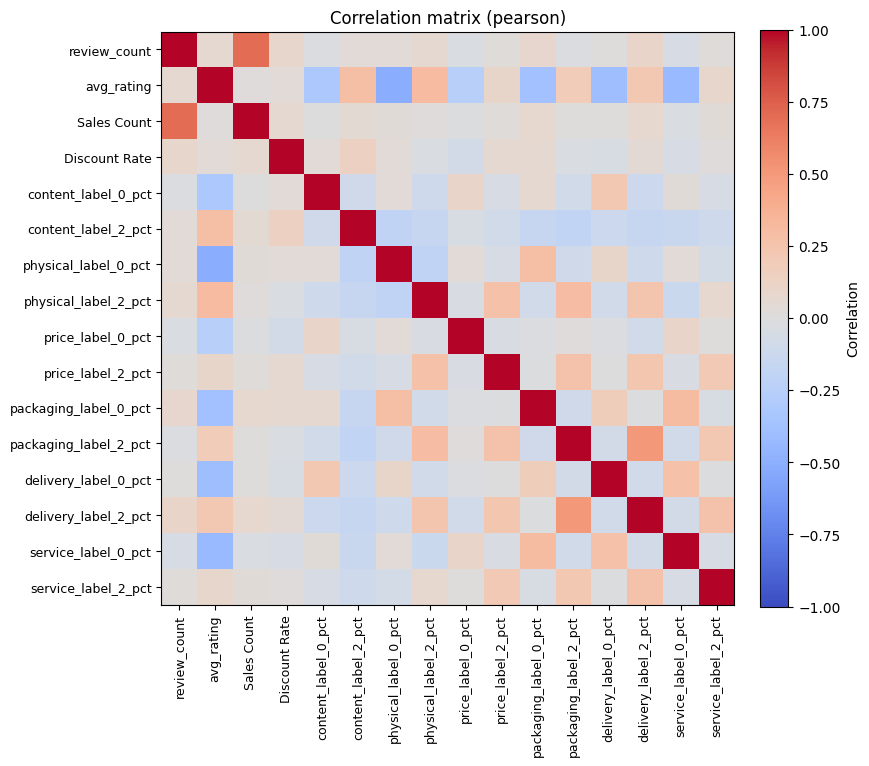

In [77]:
# Vẽ ma trận tương quan cho tập biến được chọn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# (Tuỳ chọn) đổi 'pearson' -> 'spearman' nếu muốn bền vững hơn với phân phối lệch
corr_method = 'pearson'

selected_cols = [
    'review_count',
    'avg_rating',
    'Sales Count',
    'Discount Rate',
    'content_label_0_pct',
    'content_label_2_pct',
    'physical_label_0_pct',
    'physical_label_2_pct',
    'price_label_0_pct',
    'price_label_2_pct',
    'packaging_label_0_pct',
    'packaging_label_2_pct',
    'delivery_label_0_pct',
    'delivery_label_2_pct',
    'service_label_0_pct',
    'service_label_2_pct',
]

missing = [c for c in selected_cols if c not in df.columns]
if missing:
    print('Missing columns (not found in df):', missing)

use_cols = [c for c in selected_cols if c in df.columns]
if len(use_cols) < 2:
    raise ValueError(f'Không đủ cột để tính tương quan. Found={use_cols}')

plot_df = df[use_cols].copy()
for c in use_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

corr_mat = plot_df.corr(method=corr_method)
display(corr_mat)

# Heatmap
n = corr_mat.shape[0]
fig_size = min(max(8, 0.55 * n), 18)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

im = ax.imshow(corr_mat.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title(f'Correlation matrix ({corr_method})')

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(corr_mat.columns, rotation=90, fontsize=9)
ax.set_yticklabels(corr_mat.index, fontsize=9)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.tight_layout()
plt.show()

# ma trận tương quan giữa các yếu tố tích cực


,review_count,avg_rating,Sales Count,Discount Rate,content_label_2_pct,physical_label_2_pct,price_label_2_pct,packaging_label_2_pct,delivery_label_2_pct,service_label_2_pct
review_count,1.000000,0.060970,0.699459,0.087484,0.032746,0.070257,0.019850,-0.022621,0.109202,0.020517
avg_rating,0.060970,1.000000,0.013383,0.038539,0.281392,0.306117,0.097287,0.181551,0.217520,0.092203
Sales Count,0.699459,0.013383,1.000000,0.064469,0.053893,0.015493,0.015847,0.002617,0.071977,0.026014
Discount Rate,0.087484,0.038539,0.064469,1.000000,0.134183,-0.028072,0.058548,-0.026344,0.041001,0.009883
content_label_2_pct,0.032746,0.281392,0.053893,0.134183,1.000000,-0.159562,-0.087387,-0.193850,-0.157972,-0.102932
physical_label_2_pct,0.070257,0.306117,0.015493,-0.028072,-0.159562,1.000000,0.268721,0.295764,0.239684,0.072636
price_label_2_pct,0.019850,0.097287,0.015847,0.058548,-0.087387,0.268721,1.000000,0.264108,0.227182,0.210809
packaging_label_2_pct,-0.022621,0.181551,0.002617,-0.026344,-0.193850,0.295764,0.264108,1.000000,0.502552,0.211261
delivery_label_2_pct,0.109202,0.217520,0.071977,0.041001,-0.157972,0.239684,0.227182,0.502552,1.000000,0.264513
service_label_2_pct,0.020517,0.092203,0.026014,0.009883,-0.102932,0.072636,0.210809,0.211261,0.264513,1.000000


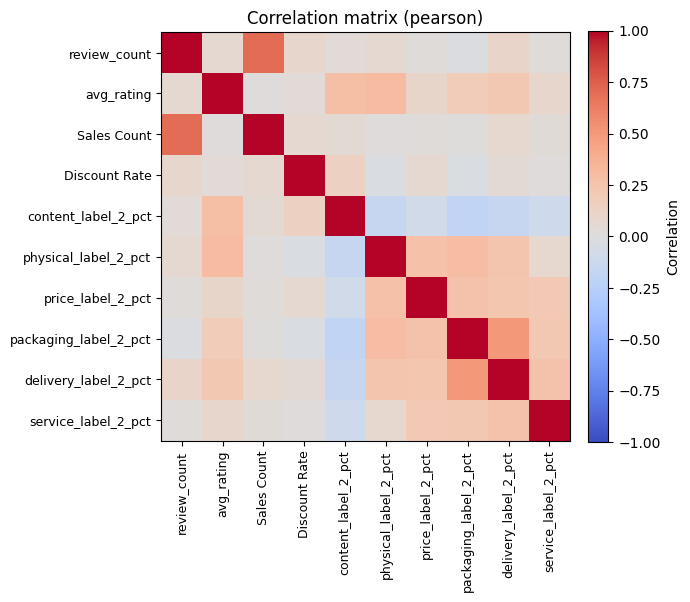

In [78]:
# Ma trận tương quan cho nhóm biến: review_count, avg_rating, Sales Count, Discount Rate và *_label_2_pct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

corr_method = 'pearson'  # đổi thành 'spearman' nếu muốn

selected_cols = [
    'review_count',
    'avg_rating',
    'Sales Count',
    'Discount Rate',
    'content_label_2_pct',
    'physical_label_2_pct',
    'price_label_2_pct',
    'packaging_label_2_pct',
    'delivery_label_2_pct',
    'service_label_2_pct',
]

missing = [c for c in selected_cols if c not in df.columns]
if missing:
    print('Missing columns (not found in df):', missing)

use_cols = [c for c in selected_cols if c in df.columns]
if len(use_cols) < 2:
    raise ValueError(f'Không đủ cột để tính tương quan. Found={use_cols}')

plot_df = df[use_cols].copy()
for c in use_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

corr_mat = plot_df.corr(method=corr_method)
display(corr_mat)

n = corr_mat.shape[0]
fig_size = min(max(7, 0.7 * n), 14)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

im = ax.imshow(corr_mat.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title(f'Correlation matrix ({corr_method})')

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(corr_mat.columns, rotation=90, fontsize=9)
ax.set_yticklabels(corr_mat.index, fontsize=9)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.tight_layout()
plt.show()

 # Ma trận tương quan giữa các yếu tố tiêu cực

,review_count,avg_rating,Sales Count,Discount Rate,content_label_0_pct,physical_label_0_pct,price_label_0_pct,packaging_label_0_pct,delivery_label_0_pct,service_label_0_pct
review_count,1.000000,0.060970,0.699459,0.087484,-0.019207,0.031797,-0.025569,0.082274,0.000383,-0.052156
avg_rating,0.060970,1.000000,0.013383,0.038539,-0.317103,-0.512235,-0.252472,-0.370035,-0.395093,-0.422564
Sales Count,0.699459,0.013383,1.000000,0.064469,-0.003912,0.030752,-0.011726,0.070348,0.006321,-0.023581
Discount Rate,0.087484,0.038539,0.064469,1.000000,0.037123,0.038195,-0.075113,0.061971,-0.039410,-0.053562
content_label_0_pct,-0.019207,-0.317103,-0.003912,0.037123,1.000000,0.036194,0.108319,0.059286,0.214449,0.030725
physical_label_0_pct,0.031797,-0.512235,0.030752,0.038195,0.036194,1.000000,0.038935,0.288467,0.098767,0.033554
price_label_0_pct,-0.025569,-0.252472,-0.011726,-0.075113,0.108319,0.038935,1.000000,-0.019938,-0.019796,0.107231
packaging_label_0_pct,0.082274,-0.370035,0.070348,0.061971,0.059286,0.288467,-0.019938,1.000000,0.175107,0.299602
delivery_label_0_pct,0.000383,-0.395093,0.006321,-0.039410,0.214449,0.098767,-0.019796,0.175107,1.000000,0.266861
service_label_0_pct,-0.052156,-0.422564,-0.023581,-0.053562,0.030725,0.033554,0.107231,0.299602,0.266861,1.000000


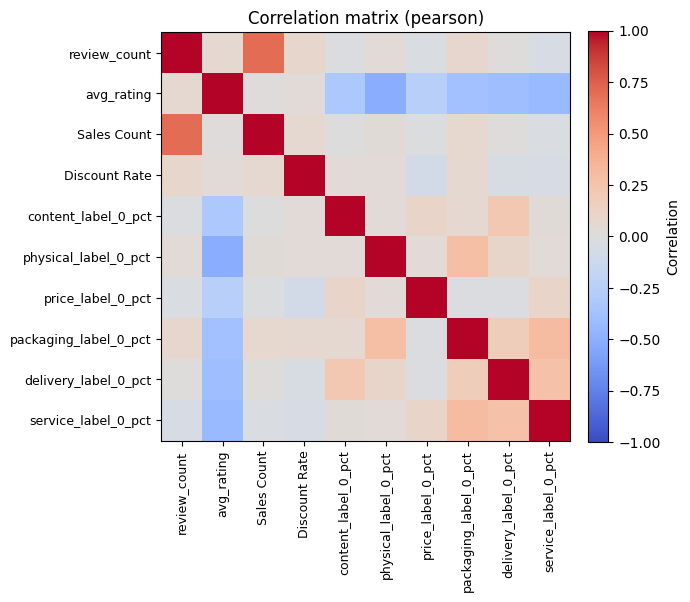

In [79]:
# Ma trận tương quan cho nhóm biến: review_count, avg_rating, Sales Count, Discount Rate và *_label_0_pct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

corr_method = 'pearson'  # đổi thành 'spearman' nếu muốn

selected_cols = [
    'review_count',
    'avg_rating',
    'Sales Count',
    'Discount Rate',
    'content_label_0_pct',
    'physical_label_0_pct',
    'price_label_0_pct',
    'packaging_label_0_pct',
    'delivery_label_0_pct',
    'service_label_0_pct',
]

missing = [c for c in selected_cols if c not in df.columns]
if missing:
    print('Missing columns (not found in df):', missing)

use_cols = [c for c in selected_cols if c in df.columns]
if len(use_cols) < 2:
    raise ValueError(f'Không đủ cột để tính tương quan. Found={use_cols}')

plot_df = df[use_cols].copy()
for c in use_cols:
    plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')

corr_mat = plot_df.corr(method=corr_method)
display(corr_mat)

n = corr_mat.shape[0]
fig_size = min(max(7, 0.7 * n), 14)
fig, ax = plt.subplots(figsize=(fig_size, fig_size))

im = ax.imshow(corr_mat.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title(f'Correlation matrix ({corr_method})')

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))
ax.set_xticklabels(corr_mat.columns, rotation=90, fontsize=9)
ax.set_yticklabels(corr_mat.index, fontsize=9)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.tight_layout()
plt.show()

# Nhóm 1: Kiểm định về tác động của cảm xúc

Giả thuyết H0: Tỉ lệ đánh giá tiêu cực không ảnh hưởng đến doanh số bán hàng của sản phẩm 

Giả thuyết H1: Có mối tương quan nghịch rõ rệt, tỉ lệ đánh giá tiêu cực càng cao thì doanh số bán hàng càng giảm 

Phương pháp kiểm định: Pearson Correlation hoặc Hồi quy tuyến tính (Linear Regression)

Tạo chỉ số tổng hợp neg_rate (0–100)

In [80]:
neg_cols = [
    "content_label_0_pct", "physical_label_0_pct", "packaging_label_0_pct",
    "delivery_label_0_pct", "service_label_0_pct", "price_label_0_pct"
]
df["neg_rate"] = df[neg_cols].mean(axis=1)   # 0..100

In [81]:
df["neg_rate"].describe()

count    1435.000000
mean        3.437282
std         5.300983
min         0.000000
25%         0.000000
50%         2.325581
75%         4.166667
max        50.000000
Name: neg_rate, dtype: float64

## Kiểm định giả thuyết H0/H1 bằng Spearman (1 phía)

H0: ρ = 0 (tỉ lệ đánh giá tiêu cực không liên quan đến Sales Count)

H1: ρ < 0 (tương quan nghịch: neg_rate tăng → Sales giảm)

In [82]:
from scipy import stats

rho, p_two = stats.spearmanr(df["neg_rate"], df["Sales Count"], nan_policy="omit")

# p-value 1 phía cho H1: rho < 0
p_one = p_two/2 if rho < 0 else 1 - p_two/2

print(f"n = {df[['neg_rate','Sales Count']].dropna().shape[0]}")
print(f"Spearman rho = {rho:.4f}")
print(f"p(two-sided) = {p_two:.6g}")
print(f"p(one-sided, H1: rho<0) = {p_one:.6g}")

n = 1435
Spearman rho = 0.2822
p(two-sided) = 1.13005e-27
p(one-sided, H1: rho<0) = 1


=> Không ủng hộ giả thuyết theo hướng âm , tức là không bác bỏ H0 theo hướng âm

## Hồi quy để nói “ảnh hưởng” hơn là “tương quan”

### Dùng OLS log_sales ~ neg_rate + review_count + discount + rating

In [83]:
import numpy as np
import statsmodels.api as sm

df["log_sales"] = np.log1p(df["Sales Count"])

X = df[["neg_rate", "review_count", "Discount Rate", "avg_rating"]].copy()
X = sm.add_constant(X)
y = df["log_sales"]

model = sm.OLS(y, X, missing="drop").fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.575
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                     483.0
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.48e-263
Time:                        15:00:54   Log-Likelihood:                -2257.0
No. Observations:                1435   AIC:                             4524.
Df Residuals:                    1430   BIC:                             4550.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.7423      0.366     15.697

Kết luận:
1) Mô hình có ý nghĩa và giải thích được mức vừa–khá
R² = 0.575 (Adj R² = 0.573): khoảng 57.5% biến thiên của log_sales = log(Sales Count + 1) được giải thích bởi 4 biến: neg_rate, review_count, Discount Rate, avg_rating.
F-test p ≈ 1.48e-263: mô hình có ý nghĩa thống kê tổng thể (ít nhất một hệ số khác 0).
2) Kết luận theo từng biến (dấu, ý nghĩa, diễn giải theo log)
Vì biến phụ thuộc là log, ta có thể diễn giải xấp xỉ theo “% thay đổi”:

review_count (coef = 0.0169, p < 0.001): ảnh hưởng dương, rất mạnh và rất chắc chắn.

Xấp xỉ: tăng 1 review → log_sales tăng 0.0169 → sales kỳ vọng tăng khoảng ~1.7% (xấp xỉ vì log).
Đây thường là biến “proxy” cho độ phổ biến/độ phủ, nên hay chi phối mạnh.
Discount Rate (coef = 0.0253, p < 0.001): ảnh hưởng dương, có ý nghĩa.

Nếu Discount Rate đang tính theo điểm phần trăm (vd +1 nghĩa là +1%), thì +1% giảm giá → sales kỳ vọng tăng khoảng ~2.5%.
neg_rate (coef = -0.0431, p < 0.001): ảnh hưởng âm, có ý nghĩa.

Tăng neg_rate 1 đơn vị → sales kỳ vọng giảm khoảng ~4.3% 
avg_rating (coef = -0.1843, p = 0.014): hệ số âm và có ý nghĩa, nhưng cần diễn giải rất cẩn thận.

Về mặt “trực giác”, rating thường kỳ vọng dương với sales; việc ra âm thường đến từ:
đa cộng tuyến (rating liên quan với neg_rate/review_count),
thiếu biến quan trọng (giá, ngành hàng, brand, vị trí hiển thị…),
rating bị “ceiling effect” (nhiều sản phẩm ~4.5–5.0),
endogeneity: sản phẩm bán chạy hút nhiều review “khó tính” → rating trung bình giảm nhẹ, hoặc nhóm hàng bán chạy vốn rating thấp nhưng rẻ/khuyến mãi mạnh.
Vì vậy kết luận đúng là: “khi giữ các biến khác cố định, rating tăng liên quan với giảm log_sales” (quan hệ điều kiện), không nên kết luận nguyên nhân.

### Dùng OLS log_sales ~ neg_rate + log_review + discount + rating

In [91]:
df["log_sales"] = np.log1p(df["Sales Count"])
df["log_review"] = np.log1p(df["review_count"])

X = df[["neg_rate", "log_review", "Discount Rate", "avg_rating"]].copy()
X = sm.add_constant(X)
y = df["log_sales"]

model = sm.OLS(y, X, missing="drop").fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     861.4
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:18:08   Log-Likelihood:                -1990.3
No. Observations:                1435   AIC:                             3991.
Df Residuals:                    1430   BIC:                             4017.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.5137      0.303     14.888

=> Kết luận: 
1. Độ phù hợp của mô hình
R² = 0.707 (Adj = 0.706)
→ Mô hình giải thích ~70.7% biến thiên của log_sales
→ Với dữ liệu hành vi (e-commerce), đây là mức rất tốt
F-statistic p-value = 0.000
→ Mô hình có ý nghĩa thống kê tổng thể
2. Review tăng 1% → Sales tăng ~0.93%
3. neg_rate — ảnh hưởng tiêu cực: tăng 1% negative rate → sales giảm ~2.6%
4. Discount Rate — tác động dương: tăng 1% discount → sales tăng ~1.28%
5. avg_rating — kết quả “ngược kỳ vọng”
Giải thích":

Có 3 khả năng:
(A) Multicollinearity với review
sản phẩm nhiều review thường có rating cao→ model “chia” ảnh hưởng

(B) Ceiling effect: 75% rating là xấp xỉ 4.93 → hệ số bị không ổn định / misleading

(C) Selection bias
sản phẩm bán chạy → nhiều review → rating bị kéo xuống (do nhiều ý kiến)
sản phẩm ít bán → rating cao (ít người đánh giá)

### Dùng Robust SE

In [84]:
# Cell 1: Chuẩn hoá cột & ép kiểu numeric

import pandas as pd
import numpy as np

TARGET = "Sales Count"
DISCOUNT = "Discount Rate"
REV = "review_count"
RATING = "avg_rating"

for col in [TARGET, DISCOUNT, REV, RATING]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df[[c for c in [TARGET, DISCOUNT, REV, RATING] if c in df.columns]].describe()

,Sales Count,Discount Rate,review_count,avg_rating
count,1435.000000,1435.000000,1435.000000,1435.000000
mean,2333.225087,22.878746,53.643206,4.561562
std,5920.341388,10.479671,77.602954,0.630375
min,1.000000,0.000000,1.000000,1.000000
25%,142.000000,20.000000,3.000000,4.500000
50%,469.000000,25.000000,15.000000,4.705882
75%,1881.500000,30.000000,74.000000,4.930195
max,76652.000000,71.000000,380.000000,5.000000


In [85]:
# Cell 2: Tạo neg_rate (%0-100) từ label_0_pct
# neg_rate = trung bình tỷ lệ tiêu cực của 6 khía cạnh: content/physical/price/packaging/delivery/service

import re

aspects = ["content", "physical", "price", "packaging", "delivery", "service"]

neg_cols = [f"{a}_label_0_pct" for a in aspects if f"{a}_label_0_pct" in df.columns]
pos_cols = [f"{a}_label_2_pct" for a in aspects if f"{a}_label_2_pct" in df.columns]

print("Found neg cols:", len(neg_cols), neg_cols)
print("Found pos cols:", len(pos_cols), pos_cols)

if len(neg_cols) == 0:
    raise ValueError("Không tìm thấy cột *_label_0_pct để tính neg_rate")

# neg_rate: mean of available negative % columns
df["neg_rate"] = df[neg_cols].mean(axis=1, skipna=True)

# (optional) clip về [0, 100] cho chắc
df["neg_rate"] = df["neg_rate"].clip(0, 100)

df[["neg_rate"] + neg_cols].head(10)

Found neg cols: 6 ['content_label_0_pct', 'physical_label_0_pct', 'price_label_0_pct', 'packaging_label_0_pct', 'delivery_label_0_pct', 'service_label_0_pct']
Found pos cols: 6 ['content_label_2_pct', 'physical_label_2_pct', 'price_label_2_pct', 'packaging_label_2_pct', 'delivery_label_2_pct', 'service_label_2_pct']


,neg_rate,content_label_0_pct,physical_label_0_pct,price_label_0_pct,packaging_label_0_pct,delivery_label_0_pct,service_label_0_pct
0,2.663230,1.546392,5.670103,0.000000,3.608247,2.577320,2.577320
1,3.630363,0.495050,9.405941,0.990099,7.920792,2.475248,0.495050
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1.289134,2.762431,2.209945,0.552486,0.552486,1.104972,0.552486
4,1.388889,0.000000,8.333333,0.000000,0.000000,0.000000,0.000000
5,4.933333,1.600000,17.600000,0.400000,4.400000,4.000000,1.600000
6,3.333333,0.000000,6.666667,6.666667,6.666667,0.000000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,2.272727,5.454545,5.454545,0.000000,0.909091,1.818182,0.000000
9,5.555556,14.285714,14.285714,0.000000,4.761905,0.000000,0.000000


In [86]:
# Cell 3: pos_rate (%0-100) để đối chiếu (nếu có cột *_label_2_pct)

if len(pos_cols) > 0:
    df["pos_rate"] = df[pos_cols].mean(axis=1, skipna=True).clip(0, 100)
    df[["pos_rate"] + pos_cols].head(10)
else:
    print("Không có đủ *_label_2_pct để tạo pos_rate")

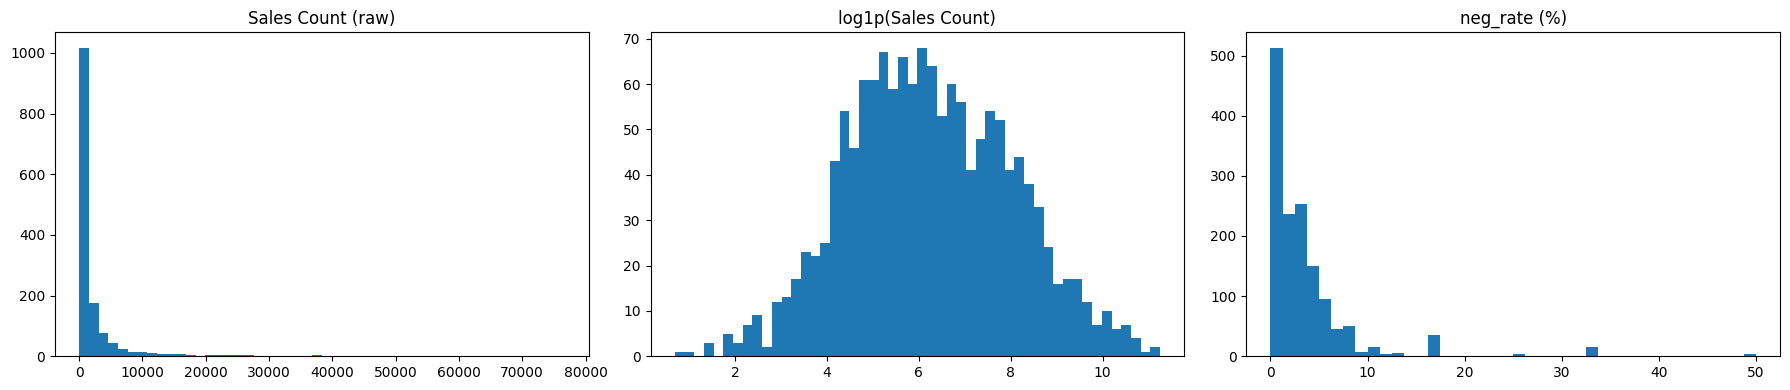

In [87]:
# Cell 4: kiểm tra phân phối

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df[TARGET].dropna(), bins=50)
axes[0].set_title("Sales Count (raw)")

axes[1].hist(np.log1p(df[TARGET].dropna()), bins=50)
axes[1].set_title("log1p(Sales Count)")

axes[2].hist(df["neg_rate"].dropna(), bins=40)
axes[2].set_title("neg_rate (%)")

plt.tight_layout()
plt.show()

In [88]:
# Cell 7: OLS regression (log1p sales)
# log_sales ~ neg_rate + log_review + rating + discount

import statsmodels.api as sm

reg_cols = [TARGET, "neg_rate", DISCOUNT, REV, RATING]
reg_cols = [c for c in reg_cols if c in df.columns]

reg_df = df[reg_cols].dropna().copy()

reg_df["log_sales"] = np.log1p(reg_df[TARGET])
reg_df["log_review"] = np.log1p(reg_df[REV])

X = reg_df[["neg_rate", "log_review", RATING, DISCOUNT]].copy()
X = sm.add_constant(X)

y = reg_df["log_sales"]

model = sm.OLS(y, X).fit(cov_type="HC3")  # robust SE
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_sales   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     725.3
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:00:55   Log-Likelihood:                -1990.3
No. Observations:                1435   AIC:                             3991.
Df Residuals:                    1430   BIC:                             4017.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.5137      0.559      8.073

Kết luận:
1. log_review — vẫn là driver chính: Review tăng 1% → Sales tăng ~0.93%
2. Discount Rate — tác động dương: Tăng discount → sales tăng , Ảnh hưởng nhỏ hơn review nhưng rõ ràng
3. neg_rate — vẫn có tác động tiêu cực: Ý nghĩa thống kê yếu hơn trước nhưng vẫn valid
4. avg_rating — vẫn âm nhưng cần cẩn trọng: biến này không ổn định
5. KL chung: Mô hình hồi quy cho thấy số lượng đánh giá (review_count) là yếu tố ảnh hưởng mạnh nhất đến doanh số, với độ co giãn xấp xỉ 0.93. Kết quả này vẫn ổn định khi sử dụng sai số chuẩn hiệu chỉnh (HC3), cho thấy tính bền vững của ước lượng.

Tỷ lệ đánh giá tiêu cực (neg_rate) có tác động tiêu cực đến doanh số, trong khi mức giảm giá có tác động tích cực. Biến điểm đánh giá trung bình (avg_rating) cho kết quả trái chiều và kém ổn định hơn, có thể do hiện tượng trần hoặc đa cộng tuyến.

Việc sử dụng robust standard errors giúp đảm bảo các kiểm định thống kê đáng tin cậy trong bối cảnh dữ liệu có khả năng tồn tại phương sai thay đổi.